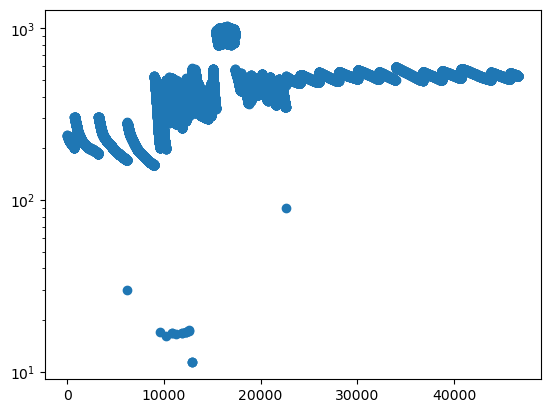

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
data = pd.read_csv("./feeds.csv")

def pickfield(field_nr):
    field = data[data[field_nr]>10]
    #field.head()
    
    return field

def plotfield(field_nr):
    field = pickfield(field_nr)
    
    ax = plt.gca()
    ax.scatter(x=field["entry_id"], y=field[field_nr])
    ax.set_yscale('log')
plotfield("field7")
# plt.show()

In [10]:
import seaborn as sns
import statsmodels.api as sm  
from statsmodels.formula.api import ols 

def select_range(field_nr, start, end):
    field = pickfield(field_nr)
    #print(field.head())
    field = field[field["entry_id"] > start]
    field = field[field["entry_id"] < end]
    return field
# field8smol['field8'] = field8smol['field8'].shift(-24) - field8smol['field8']
# field8smol = field8smol[field8smol["entry_id"] % 24 == 0]

# sns.residplot(x='entry_id', y='field8', data=field8smol)
# plt.xlabel("entry id")
# plt.ylabel("Residuals")
# plt.show()

#select_range("field7", 43795,45795)
def residual_graph(field_nr, start, end):

    data_field = select_range(field_nr, start, end)
    
    lm = ols(f'{field_nr} ~ entry_id', data=data_field).fit()
    print(lm.summary()) 
    fig = plt.figure(figsize=(14, 8))
    fig = sm.graphics.plot_regress_exog(lm, 'entry_id', fig=fig)  

#residual_graph("field7", 43795 ,45795)
#residual_graph("field7", 43795 ,44795)
# ax1 = plt.gca()
# ax1.scatter(x=field8smol["entry_id"], y=field8smol["field8"])

# plt.show()


                    Breakpoint Regression Results                     
No. Observations                     1999
No. Model Parameters                    4
Degrees of Freedom                   1995
Res. Sum of Squares               913.442
Total Sum of Squares          2.14248e+05
R Squared                        0.995737
Adjusted R Squared               0.995728
Converged:                           True
                    Estimate      Std Err            t        P>|t|       [0.025       0.975]
----------------------------------------------------------------------------------------------------
const                1225.71         3.83       319.62           0.0       1218.2       1233.2
alpha1            -0.0253943     8.67e-05       -293.0           0.0    -0.025564    -0.025224
beta1              0.0136117     0.000108       126.04             -       0.0134     0.013823
breakpoint1          44696.5         4.47            -             -   4.4688e+04   4.4705e+04
-----------------

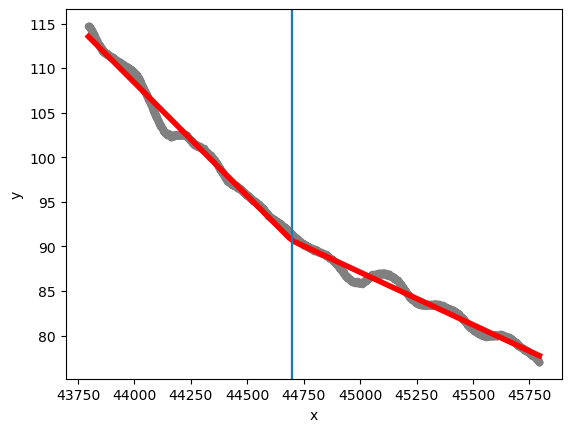

In [31]:
#!pip install piecewise-regression
import piecewise_regression
pw_fit = piecewise_regression.Fit(list(field8smol["entry_id"]), list(field8smol["field7"]), n_breakpoints=1)
pw_fit.summary()

pw_fit.plot_data(color="grey", s=20)
# Pass in standard matplotlib keywords to control any of the plots
pw_fit.plot_fit(color="red", linewidth=4)
pw_fit.plot_breakpoints()
pw_fit.plot_breakpoint_confidence_intervals()
plt.xlabel("x")
plt.ylabel("y")
plt.show()
plt.close()

Cycle lengths: [1483 1931 1994 1964 2221 1703 2800 1980 2017 3052 2000]


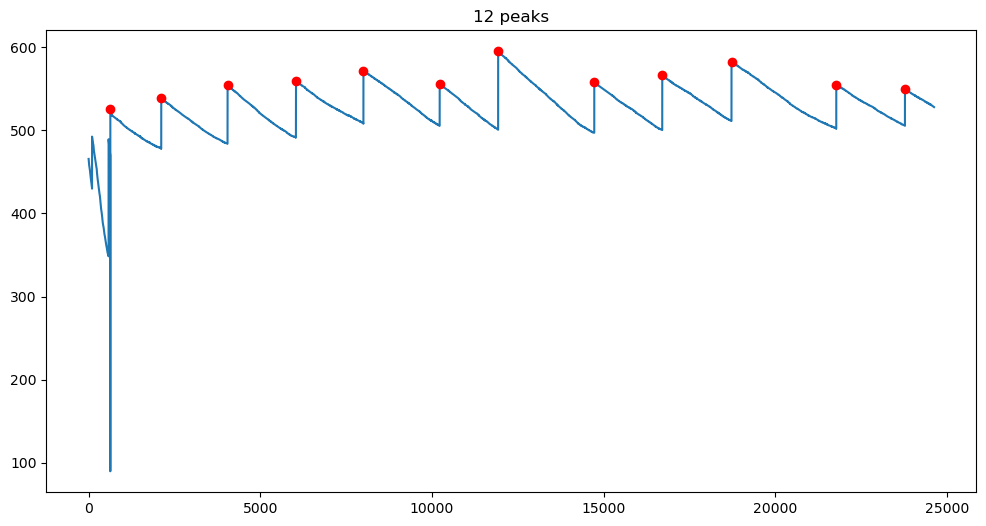

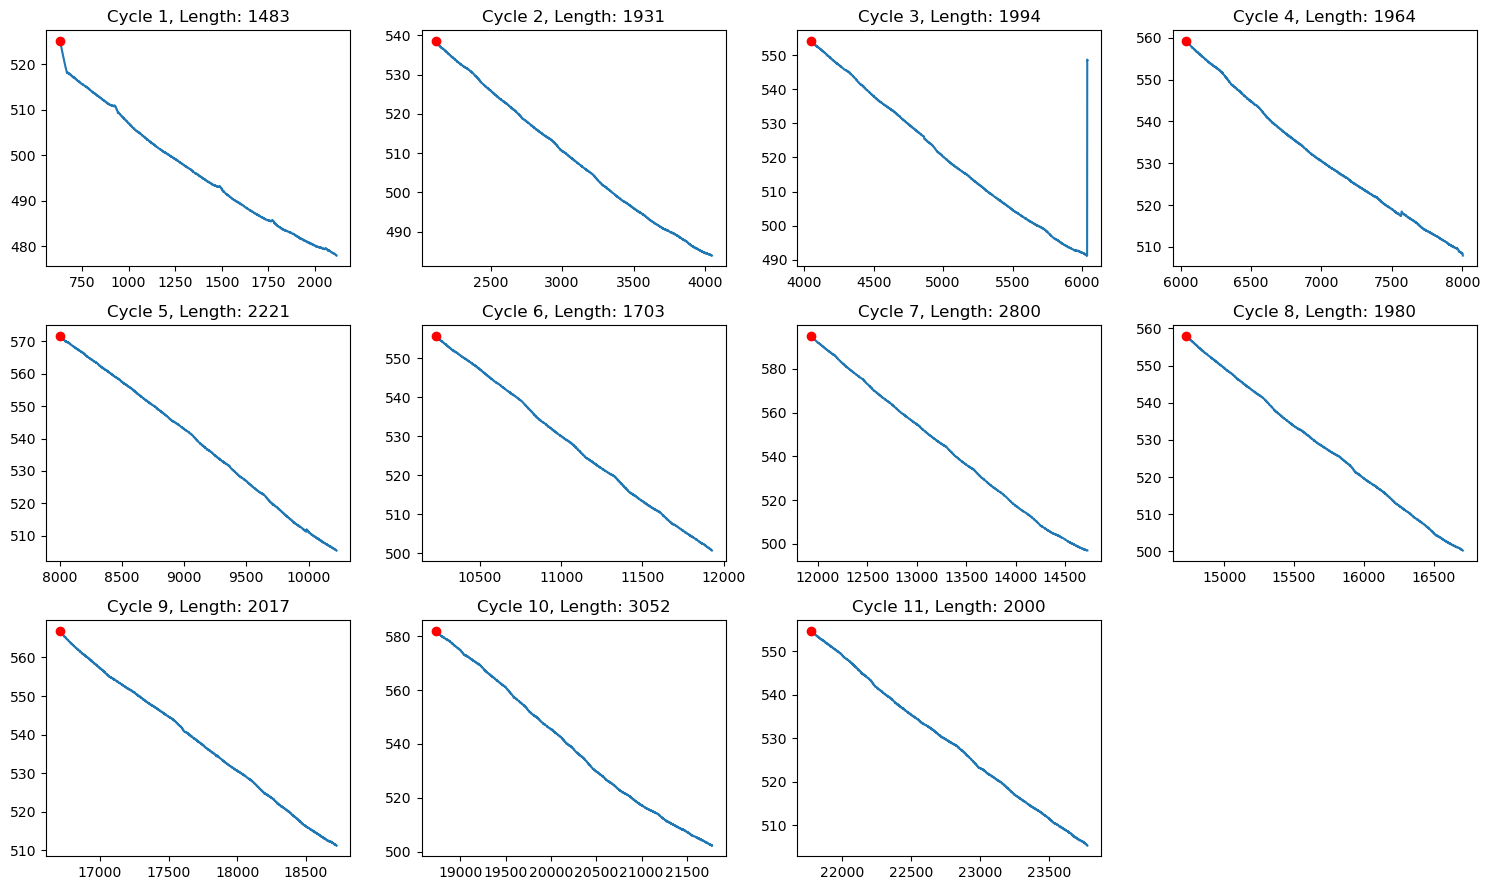

In [2]:
from scipy.signal import find_peaks

y = field7[field7["entry_id"] >22000]["field7"]
y = y.reset_index(drop=True)
x = np.arange(len(y))
#x = field7[field7["entry_id"] >22000]["entry_id"]


peaks, _ = find_peaks(y, distance=1000, prominence=0.5)   # distance prevents false peaks, so does prominence


cycle_lengths = np.diff(peaks)

print("Cycle lengths:", cycle_lengths)
plt.figure(figsize=(12, 6))
plt.plot(x, y)
plt.plot(x[peaks], y[peaks], "ro")
plt.title(f"{len(peaks)} peaks")

cycles = len(peaks)-1

if cycles>0:
    n_cols = 4
    n_rows = int(np.ceil(cycles/n_cols))

    plt.figure(figsize=(15,3*n_rows))
    for i in range(cycles):
        start = peaks[i]
        end = peaks[i+1]
        plt.subplot(n_rows, n_cols, i+1)
        plt.plot(x[start:end], y[start:end])
        plt.plot(x[start], y[start], "ro")
        plt.title(f"Cycle {i+1}, Length: {cycle_lengths[i]}")
        
        plt.tight_layout()
plt.show()

                   created_at  entry_id  field1   field2  field3  field4  \
39  2023-12-07T11:14:49+02:00        40  820.30  1423.08  944.24  207.46   
40  2023-12-07T11:44:58+02:00        41  820.08  1422.17  943.95  207.16   
41  2023-12-07T12:15:04+02:00        42  819.60  1421.65  943.75  206.89   
42  2023-12-07T12:45:12+02:00        43  819.09  1421.13  943.61  206.56   
43  2023-12-07T13:15:21+02:00        44  818.56  1420.66  943.54  206.16   

    field5  field6  field7  field8  latitude  longitude  elevation  status  
39  270.55  707.60  237.70  844.29       NaN        NaN        NaN     NaN  
40  270.41  707.47  237.63  843.93       NaN        NaN        NaN     NaN  
41  270.28  707.27  237.51  843.42       NaN        NaN        NaN     NaN  
42  270.28  707.09  237.36  842.95       NaN        NaN        NaN     NaN  
43  270.29  706.98  237.31  842.42       NaN        NaN        NaN     NaN  


<Axes: xlabel='entry_id', ylabel='field8'>

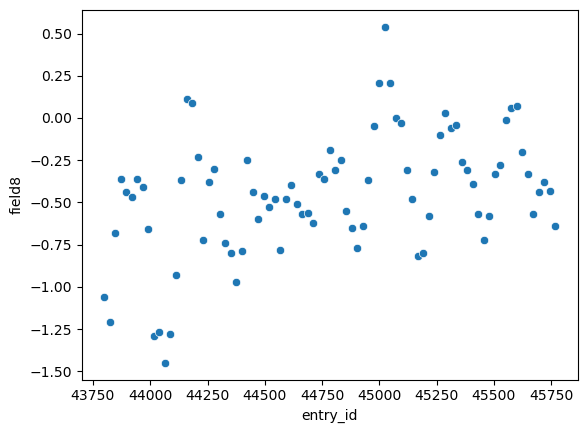

In [51]:

field = select_range("field8", 43795, 45795)
field['field8'] = (field['field8'].shift(-24) - field['field8'])
field = field[field["entry_id"] % 24 == 0]

sns.scatterplot(x='entry_id', y='field8', data=field)

                   created_at  entry_id  field1   field2  field3  field4  \
39  2023-12-07T11:14:49+02:00        40  820.30  1423.08  944.24  207.46   
40  2023-12-07T11:44:58+02:00        41  820.08  1422.17  943.95  207.16   
41  2023-12-07T12:15:04+02:00        42  819.60  1421.65  943.75  206.89   
42  2023-12-07T12:45:12+02:00        43  819.09  1421.13  943.61  206.56   
43  2023-12-07T13:15:21+02:00        44  818.56  1420.66  943.54  206.16   

    field5  field6  field7  field8  latitude  longitude  elevation  status  
39  270.55  707.60  237.70  844.29       NaN        NaN        NaN     NaN  
40  270.41  707.47  237.63  843.93       NaN        NaN        NaN     NaN  
41  270.28  707.27  237.51  843.42       NaN        NaN        NaN     NaN  
42  270.28  707.09  237.36  842.95       NaN        NaN        NaN     NaN  
43  270.29  706.98  237.31  842.42       NaN        NaN        NaN     NaN  


<Axes: xlabel='entry_id', ylabel='field4'>

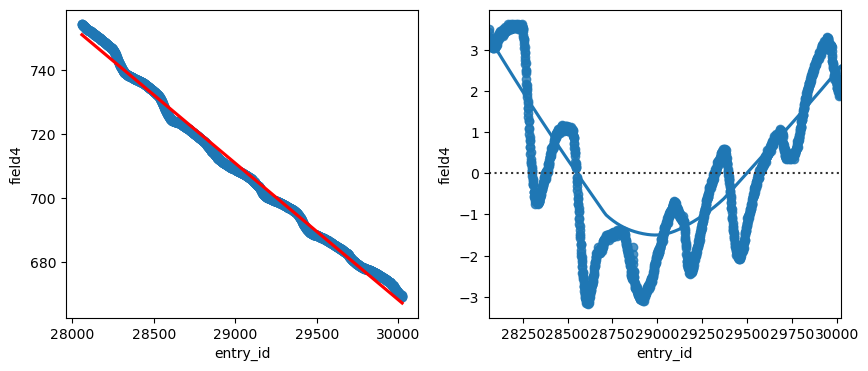

In [54]:
field = select_range("field4", 28059, 30024)
# field['field8'] = (field['field8'].shift(-24) - field['field8'])
# field = field[field["entry_id"] % 24 == 0]
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.regplot(x='entry_id', y='field4', data=field, order = 1, line_kws=dict(color="r"), ax=axs[0])
sns.residplot(x='entry_id', y='field4', data=field, ax=axs[1], lowess = True)
# sns.residplot(x='entry_id', y='field8', data=field8smol)
# plt.xlabel("entry id")
# plt.ylabel("Residuals")
# plt.show()

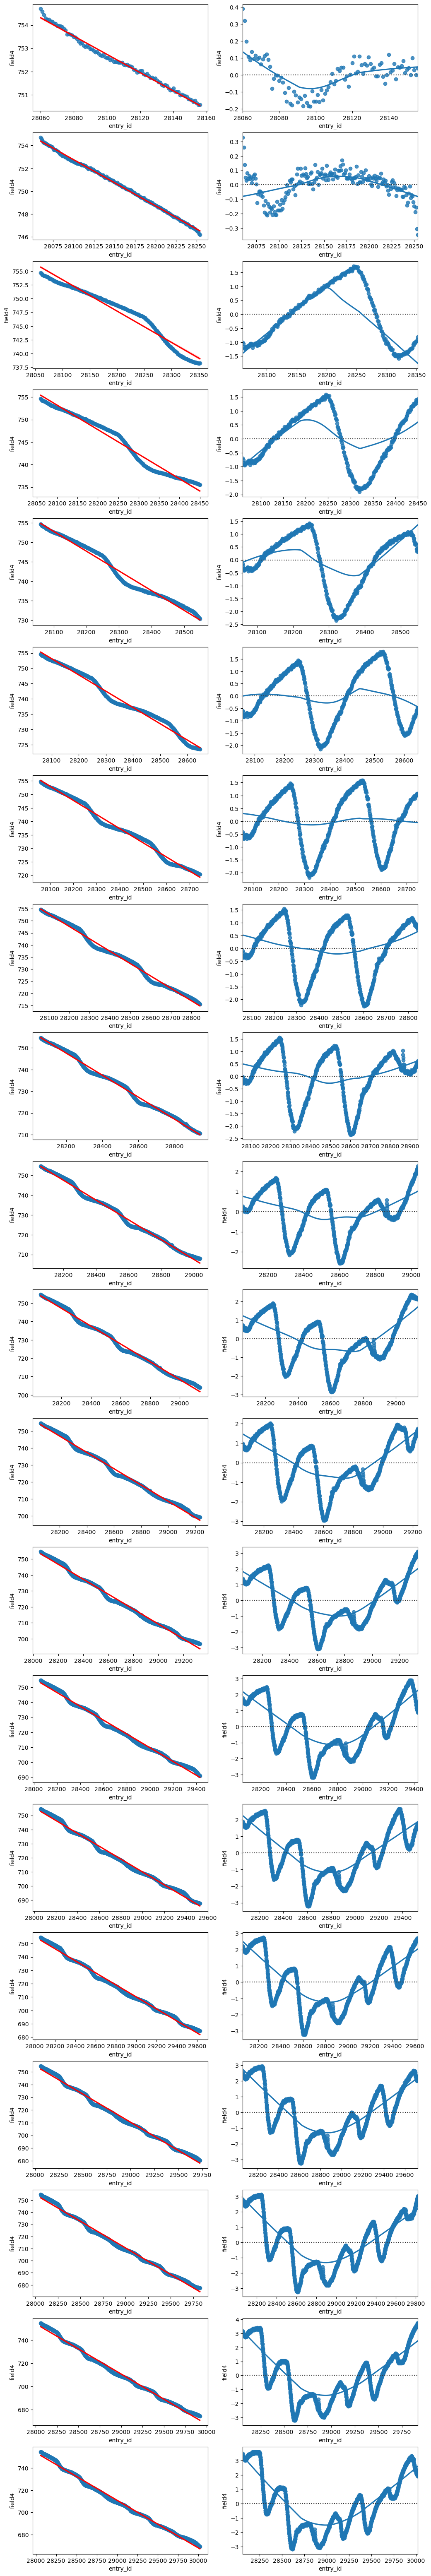

In [17]:
lower = 28059
upper = 30024
diff = upper-lower
chunks = 20

fig, axs = plt.subplots(chunks, 2, figsize=(12, chunks*4))
for i in range(chunks):
    chunkdiff = diff//chunks
    currentupper = lower + (i+1)*chunkdiff 
    field = select_range("field4",lower, currentupper)


    sns.regplot(x='entry_id', y='field4', data=field, order = 1, line_kws=dict(color="r"), ax=axs[i,0])
    sns.residplot(x='entry_id', y='field4', data=field, order = 1, ax=axs[i, 1], lowess = True)

In [ ]:
data_30 = data.iloc[:22673]
data_5 = data.iloc[22673:]

data_30.to_csv("feeds_30.csv